<a href="https://colab.research.google.com/github/AyushiB56/Neural-Network/blob/main/vanilla_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import os
import glob
import string
import unicodedata
import random
import io

In [2]:

every_ascii_character= string.ascii_letters + " .,:;"
len_of_char= len(every_ascii_character)

In [3]:


def unicode_to_ascii(s):
  return ''. join(c for c in unicodedata.normalize('NFD',s) if  unicodedata.category(c) != 'Mn' and c in every_ascii_character)

In [4]:
def load_data():
  countries=[]
  country_people_name={}
  def find_files(path):
    return glob.glob(path)
  def read_lines(filename):
    lines= io.open(filename,encoding='utf-8').read().strip().split('\n')

    return [unicode_to_ascii(line) for line in lines]

  for files in find_files('sample_data/data/*.txt'):
    country =  os.path.splitext(os.path.basename(files))[0]

    countries.append(country)

    lines= read_lines(files)
    country_people_name[country]=lines
  return country_people_name,countries





In [5]:
import numpy as np

In [6]:
def find_letter(letter):
  return every_ascii_character.find(letter)

In [7]:
def letter_to_ohe(letter):
  letter_to_tensor= torch.zeros(1,len_of_char)
  letter_to_tensor[0][find_letter(letter)]=1
  return letter_to_tensor

In [8]:
def line_to_ohe(line):
  tensor = torch.zeros(len(line), 1, len_of_char)
  for i, letter in enumerate(line):
        tensor[i][0][find_letter(letter)] = 1
  return tensor




In [9]:
def random_set(country_people_name,countries):
  def random_choice(a):
    return a[random.randint(0,len(countries)-1)]
  country= random_choice(countries)
  country_tensor= torch.tensor([countries.index(country)],dtype=torch.long)

  people_name= random_choice(country_people_name[country])
  line_tensor= line_to_ohe(people_name)
  return country_tensor,country,people_name,line_tensor

In [10]:
def random_training_example(category_lines, all_categories):

    def random_choice(a):
        random_idx = random.randint(0, len(a) - 1)
        return a[random_idx]

    category = random_choice(all_categories)
    line = random_choice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = line_to_ohe(line)
    return category, line, category_tensor, line_tensor

In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt




In [12]:
class Rnn_module(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):

    super(Rnn_module, self).__init__()
    self.hidden_size= hidden_size
    self.i2h=nn.Linear(input_size + hidden_size, hidden_size)
    self.i2o=nn.Linear(input_size + hidden_size, output_size)
    self.softmax= nn.LogSoftmax(dim=1)
  def forward(self, input_tensor, hidden_tensor):
    combined= torch.cat((input_tensor, hidden_tensor),1)
    hidden = torch.tanh(self.i2h(combined))
    output = self.i2o(combined)
    output = self.softmax(output)


    return output, hidden
  def init_hidden(self):
    return torch.zeros(1, self.hidden_size)


In [13]:
country_people_name,countries= load_data()


hidden_size=128
rnn= Rnn_module(len_of_char,hidden_size,len(countries))
optimizer= torch.optim.Adam(rnn.parameters(), lr=0.005)
loss= nn.NLLLoss()
def train(line_tensor,country_tensor):

  hidden= rnn.init_hidden()


  for i in range(len(line_tensor)):
      output, hidden = rnn(line_tensor[i], hidden)
  loss_value= loss(output,country_tensor)
  optimizer.zero_grad()
  loss_value.backward()
  optimizer.step()


    #print("loss per epoch", loss_value.item())
  return output,loss_value.item()



In [14]:
def category_output(output):
  max_out= torch.argmax(output).item()
  return countries[max_out]

In [15]:
loss_epoch= []

In [16]:
all_loss=[]
current_loss=0
for i in range(100000):
  country_tensor,country,people_name,line_tensor= random_set(country_people_name,countries)
  output,train_loss=train(line_tensor,country_tensor)
  current_loss+=train_loss
  print(current_loss)

  if (i+1)%1000==0:
    all_loss.append(current_loss/1000)
    current_loss=0

Streaming output truncated to the last 5000 lines.
2.940101146697998
5.438435792922974
8.041702270507812
8.043734034756199
8.200948020676151
8.22974831261672
8.25808670395054
14.95046141021885
14.950461887055894
14.952812314033395
15.925296247005349
19.5969824194907
19.59904570970673
20.594551042653507
21.486117915250247
21.950955049134677
26.795809403993076
27.17830802593369
27.33495281729836
28.05656711850304
28.38990895543236
28.39002255543153
28.39526638907398
32.35033926886524
32.853291606130256
33.54798946303333
39.06261501234974
39.4293077937981
39.45141619403864
39.97326314409281
45.11964929063822
45.13798337762262
45.13798337762262
45.25821256225015
47.10629534308816
47.106475213724366
47.106475213724366
48.81277308817505
49.72794393654465
50.01095158811211
50.29838700051903
50.92054105754494
50.997658865708104
51.432139085787526
55.91320149804949
55.92083411495685
57.96131282131671
60.68229418079852
60.724325845199814
66.27924794908165
66.27932364411379
66.27932364411379
66.2

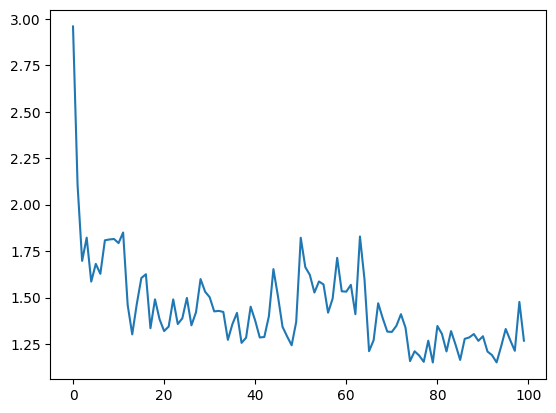

In [17]:
plt.figure()
plt.plot(all_loss)
plt.show()

In [18]:

def predict(input_line):
    print(f"\n> {input_line}")
    with torch.no_grad():
        line_tensor = line_to_ohe(input_line)

        hidden = rnn.init_hidden()

        for i in range(line_tensor.size()[0]):
            output, hidden = rnn(line_tensor[i], hidden)

        guess = category_output(output)
        print(guess)


In [19]:
predict('Addis')


> Addis
English
